# OpenAI VLM API Smoke Test

This notebook runs an end-to-end API smoke test for VLM labeling with a single combined JSON prompt.

## Where to run
- Preferred: from a container in the same Docker network as AVSP services.
- Container endpoints: `http://master-server:9002` and `http://storage-server:9012`.
- Host fallback endpoints are also supported: `http://localhost:9012` and `http://localhost:9023`.

## What this notebook does
1. Resolves reachable Master/Storage API endpoints.
2. Pulls a small sample of object IDs from Storage API (no synthetic image generation).
3. Reads existing VLM schema fields from Master API.
4. Starts `/vlm/backfill` in combined JSON mode (API-only when `dry_run=True`).
5. Polls `/jobs` until completion and prints logs.
6. Optionally fetches resulting annotations for sampled object IDs (when writing is enabled).


In [5]:
import json
import os
import time
import urllib.error
import urllib.parse
import urllib.request
from typing import Any, Dict, List, Optional

# Defaults target in-container networking first.
MASTER_URL_CANDIDATES = [
    os.getenv("MASTER_URL", "http://master-server:9002"),
    "http://localhost:9012",
]
STORAGE_URL_CANDIDATES = [
    os.getenv("STORAGE_URL", "http://storage-server:9012"),
    "http://localhost:9023",
]

DATASET_FILTER = "waymo"
SAMPLE_SIZE = 8
BATCH_SIZE = 4
POLL_SEC = 3
POLL_TIMEOUT_SEC = 60 * 60

# Fail fast if VLM service is not running with OpenAI backend.
REQUIRE_OPENAI_BACKEND = True

# Keep True to save annotations and read them back in this notebook.
WRITE_ANNOTATIONS = True

# Use OpenAI Batch API for lower cost on larger samples (slower, async under the hood).
USE_OPENAI_BATCH_API = True

# Explicit subset of VLM field names to backfill (recommended).
# Example: ["car_count", "has_crosswalk", "scene_type"]
TARGET_FIELD_NAMES: List[str] = ["car_count", "has_crosswalk", "scene_type"]

# If True and TARGET_FIELD_NAMES is empty, notebook will use all fields from current schema.
USE_ALL_EXISTING_FIELDS = False

# Optional: one long custom prompt. If empty, prompt is auto-built from schema fields.
CUSTOM_COMBINED_PROMPT = ""

# How many prompt characters to print before running backfill.
SHOW_PROMPT_PREVIEW_CHARS = 4000


In [6]:
def _request(base_url: str, method: str, path: str, payload: Optional[Dict[str, Any]] = None, params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    url = f"{base_url.rstrip('/')}" + path
    if params:
        query = urllib.parse.urlencode({k: v for k, v in params.items() if v is not None and str(v) != ""})
        if query:
            url = f"{url}?{query}"

    data = None
    headers = {}
    if payload is not None:
        data = json.dumps(payload).encode("utf-8")
        headers["Content-Type"] = "application/json"

    req = urllib.request.Request(url=url, data=data, headers=headers, method=method.upper())
    try:
        with urllib.request.urlopen(req, timeout=60) as resp:
            raw = resp.read().decode("utf-8")
            return json.loads(raw) if raw else {}
    except urllib.error.HTTPError as exc:
        body = exc.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"HTTP {exc.code} {method.upper()} {url}: {body}") from exc


def _resolve_reachable_base_url(candidates: List[str], health_path: str) -> str:
    errors = []
    for base in candidates:
        try:
            _request(base, "GET", health_path)
            return base.rstrip("/")
        except Exception as exc:  # noqa: BLE001
            errors.append(f"{base} -> {exc}")
    raise RuntimeError("No reachable endpoint. Tried:\\n" + "\\n".join(errors))


In [7]:
MASTER_URL = _resolve_reachable_base_url(MASTER_URL_CANDIDATES, "/health")
STORAGE_URL = _resolve_reachable_base_url(STORAGE_URL_CANDIDATES, "/health")

print("MASTER_URL:", MASTER_URL)
print("STORAGE_URL:", STORAGE_URL)

health = _request(MASTER_URL, "GET", "/health")
system_info = _request(MASTER_URL, "GET", "/system-info")
print("master health:", health.get("status"))
vlm_service = system_info.get("services", {}).get("vlm", {})
print("vlm runtime:", vlm_service)

runtime = vlm_service.get("runtime", {}) if isinstance(vlm_service, dict) else {}
attn_type = str(runtime.get("attn_type", "")).strip().lower()
model_name = str(vlm_service.get("model", "")).strip()
is_openai_backend = attn_type == "remote-api"

if REQUIRE_OPENAI_BACKEND and not is_openai_backend:
    raise RuntimeError(
        "VLM backend is not OpenAI. "
        f"Current model={model_name!r}, attn_type={attn_type!r}. "
        "Set VLM_BACKEND=OPENAI and OPENAI_API_KEY/VLM_OPENAI_API_KEY, then restart containers."
    )


MASTER_URL: http://master-server:9002
STORAGE_URL: http://storage-server:9012
master health: ok
vlm runtime: {'name': 'vlm', 'endpoint': 'http://vlm-worker:8001', 'reachable': True, 'status': 'ok', 'model': 'gpt-5.4-mini', 'device': 'cpu', 'runtime': {'configured_device': 'cpu', 'selected_device': 'cpu', 'torch_cuda_available': False, 'torch_mps_available': False, 'cuda_device_count': 0, 'cuda_device_name': None, 'dtype': 'float32', 'attn_type': 'remote-api'}, 'memory': {'process_rss_mb': 596.52, 'gpu_allocated_mb': 0.0, 'gpu_reserved_mb': 0.0, 'gpu_total_mb': 0.0, 'gpu_free_mb': 0.0}, 'counters': {'received': 0, 'completed': 0, 'in_progress': 0}, 'error': ''}


In [8]:
def list_storage_sample(limit: int, dataset: Optional[str] = None) -> List[Dict[str, Any]]:
    items_out: List[Dict[str, Any]] = []
    cursor = None

    while len(items_out) < limit:
        page = _request(STORAGE_URL, "GET", "/objects", params={"limit": 200, "cursor": cursor})
        items = page.get("items", [])
        if not items:
            break

        for item in items:
            object_id = str(item.get("object_id", "")).strip()
            bucket = str(item.get("bucket", "")).strip()
            if not object_id:
                continue
            if dataset and bucket.lower() != dataset.lower():
                continue
            items_out.append({"object_id": object_id, "bucket": bucket})
            if len(items_out) >= limit:
                break

        cursor = page.get("next_cursor")
        if not cursor:
            break

    return items_out


sample_items = list_storage_sample(SAMPLE_SIZE, DATASET_FILTER)
sample_object_ids = [x["object_id"] for x in sample_items]

print(f"sample objects selected: {len(sample_object_ids)}")
for row in sample_items[:10]:
    print(row)

if not sample_object_ids:
    raise RuntimeError("No sample objects found in storage. Load a dataset first.")


sample objects selected: 8
{'object_id': '0007e91db46d0f76e4010a1ffd83c574', 'bucket': 'waymo'}
{'object_id': '001ed38a561b2927fe9884362909ce28', 'bucket': 'waymo'}
{'object_id': '0021349e3678529234690d22e96861de', 'bucket': 'waymo'}
{'object_id': '002493d8fa7e3a5c5127543e0e00eac6', 'bucket': 'waymo'}
{'object_id': '00272fe9035971844c5cec6aafd0707e', 'bucket': 'waymo'}
{'object_id': '002c8235b0c50a028e5c3a63aea154da', 'bucket': 'waymo'}
{'object_id': '002d8b5f7808e54a0d424a95b3b64c2c', 'bucket': 'waymo'}
{'object_id': '003e20280f36c71d651526cbba34747a', 'bucket': 'waymo'}


In [9]:
fields_resp = _request(MASTER_URL, "GET", "/vlm/fields")
all_fields = fields_resp.get("fields", [])
if not all_fields:
    raise RuntimeError("No VLM fields configured. Configure schema once via /vlm/fields before backfill.")

existing_map = {str(f.get("field_name", "")).strip(): f for f in all_fields}
existing_names = [name for name in existing_map.keys() if name]

if TARGET_FIELD_NAMES:
    missing = sorted([name for name in TARGET_FIELD_NAMES if name not in existing_map])
    if missing:
        raise RuntimeError(f"Requested fields are missing in schema: {missing}")
    selected_field_names = list(TARGET_FIELD_NAMES)
elif USE_ALL_EXISTING_FIELDS:
    selected_field_names = existing_names
else:
    raise RuntimeError(
        "TARGET_FIELD_NAMES is empty. Set 1..N explicit fields or set USE_ALL_EXISTING_FIELDS=True."
    )

selected_fields = [existing_map[name] for name in selected_field_names]
print("total configured VLM fields:", len(existing_names))
print("selected fields:", selected_field_names)


total configured VLM fields: 17
selected fields: ['car_count', 'has_crosswalk', 'scene_type']


In [10]:
if str(CUSTOM_COMBINED_PROMPT).strip():
    combined_prompt = str(CUSTOM_COMBINED_PROMPT).strip()
else:
    lines = [
        "You are an image labeling module for autonomous driving data.",
        "Return ONLY one compact JSON object (no markdown, no explanations).",
        "Use exactly these keys:",
    ]
    for field in selected_fields:
        name = str(field.get("field_name", "")).strip()
        response_type = str(field.get("response_type", "text")).strip() or "text"
        prompt = str(field.get("prompt", "")).strip()
        lines.append(f"- {name}: type={response_type}; requirement={prompt}")
    combined_prompt = "\\n".join(lines)

backfill_payload = {
    "field_names": selected_field_names,
    "limit": len(sample_object_ids),
    "batch_size": BATCH_SIZE,
    "overwrite_existing": True,
    "dry_run": not WRITE_ANNOTATIONS,
    "max_new_tokens": 256,
    "combine_fields_into_json": True,
    "combined_prompt": combined_prompt,
    "use_openai_batch_api": USE_OPENAI_BATCH_API,
}
if DATASET_FILTER:
    backfill_payload["dataset"] = DATASET_FILTER

print("backfill field_names:", backfill_payload["field_names"])
print("combined prompt chars:", len(combined_prompt))
preview_chars = max(int(SHOW_PROMPT_PREVIEW_CHARS), 0)
print("\n--- combined prompt preview ---")
if preview_chars == 0:
    print("(prompt preview disabled)")
elif len(combined_prompt) <= preview_chars:
    print(combined_prompt)
else:
    print(combined_prompt[:preview_chars] + "\n...<truncated>...")

start_resp = _request(MASTER_URL, "POST", "/vlm/backfill", payload=backfill_payload)
job_id = start_resp["job_id"]
print("job started:", job_id)
print("dry_run:", backfill_payload["dry_run"])
print("use_openai_batch_api:", backfill_payload["use_openai_batch_api"])


backfill field_names: ['car_count', 'has_crosswalk', 'scene_type']
combined prompt chars: 1300

--- combined prompt preview ---
You are an image labeling module for autonomous driving data.\nReturn ONLY one compact JSON object (no markdown, no explanations).\nUse exactly these keys:\n- car_count: type=number; requirement=Count the number of visible passenger cars\n- has_crosswalk: type=yes_no; requirement=Is there a visible crosswalk in the scene?\n- scene_type: type=category; requirement=Classify the driving area type.
Allowed labels:
highway, urban_street, residential, intersection, parking_lot, rural_road, tunnel, bridge, roundabout, unknown.

Definitions:
- highway: high-speed multi-lane road or expressway.
- urban_street: city street with buildings, sidewalks, parked cars, traffic lights, or crosswalks.
- residential: quiet neighborhood street with houses, driveways, parked cars, or low traffic.
- intersection: junction where roads meet; use if the junction is relevant to ego driv

In [11]:
def get_job_by_id(job_id: str) -> Dict[str, Any]:
    jobs_payload = _request(MASTER_URL, "GET", "/jobs")
    for job in jobs_payload.get("jobs", []):
        if job.get("job_id") == job_id:
            return job
    raise RuntimeError(f"Job not found: {job_id}")


deadline = time.time() + POLL_TIMEOUT_SEC
last_snapshot = None
final_job = None

while time.time() < deadline:
    job = get_job_by_id(job_id)
    snapshot = (
        job.get("status"),
        job.get("progress"),
        job.get("total_seen"),
        job.get("total_inserted"),
        job.get("total_tasks_completed"),
        job.get("total_tasks_planned"),
        job.get("current_scene_tasks_completed"),
        job.get("current_scene_tasks_total"),
    )
    if snapshot != last_snapshot:
        print(
            f"status={snapshot[0]} progress={snapshot[1]}% "
            f"seen={snapshot[2]} inserted={snapshot[3]} "
            f"tasks={snapshot[4]}/{snapshot[5]} "
            f"scene_tasks={snapshot[6]}/{snapshot[7]}"
        )
        last_snapshot = snapshot

    if job.get("status") in {"success", "error", "cancelled"}:
        final_job = job
        break

    time.sleep(POLL_SEC)

if final_job is None:
    raise TimeoutError(f"Job did not finish within {POLL_TIMEOUT_SEC} seconds")

print("\\nFinal status:", final_job.get("status"))
print("Errors:", len(final_job.get("errors", [])))
print("Parse warnings:", final_job.get("parse_warnings_total", 0))
print("Job field_names:", final_job.get("field_names", []))
if final_job.get("errors", []):
    print(final_job["errors"])

status=running progress=0% seen=0 inserted=0 tasks=0/8 scene_tasks=0/1
status=running progress=0% seen=0 inserted=0 tasks=1/8 scene_tasks=0/1
status=running progress=0% seen=0 inserted=0 tasks=2/8 scene_tasks=0/1
status=running progress=0% seen=0 inserted=0 tasks=3/8 scene_tasks=0/1
status=running progress=0% seen=0 inserted=0 tasks=4/8 scene_tasks=0/1
status=running progress=0% seen=0 inserted=0 tasks=5/8 scene_tasks=0/1
status=running progress=0% seen=0 inserted=0 tasks=7/8 scene_tasks=0/1
status=success progress=100% seen=0 inserted=0 tasks=8/8 scene_tasks=0/0
\nFinal status: success
Errors: 0
Parse warnings: 0
Job field_names: ['car_count', 'has_crosswalk', 'scene_type']


In [12]:
job = get_job_by_id(job_id)
print("job type:", job.get("job_type"))
print("tasks planned/completed:", job.get("total_tasks_planned"), job.get("total_tasks_completed"))
print("annotations saved:", job.get("total_inserted"))
print("parse warnings:", job.get("parse_warnings_total", 0))

errors = job.get("errors", []) or []
print("errors:", len(errors))
if errors:
    print("first error:", json.dumps(errors[0], ensure_ascii=False)[:1200])

print("\n--- last job log lines ---")
for line in job.get("job_log", [])[-40:]:
    print(line)


job type: backfill_vlm
tasks planned/completed: 8 8
annotations saved: 0
parse warnings: 0
errors: 0

--- last job log lines ---
[2026-05-11 23:52:39] VLM backfill started: limit=8, fields=3, dataset=waymo, combine_fields_into_json=True
[2026-05-11 23:52:39] Dataset visibility: hidden=<none>
[2026-05-11 23:52:39] Objects selected: 8 (dataset=waymo)
[2026-05-11 23:52:39] Backfill VLM started: limit=8, batch_size=4, fields=3, dry_run=False, overwrite_existing=True
[2026-05-11 23:52:39] Backfill VLM runtime options: retry_empty_values=True, field_chunk_size=4, base_max_new_tokens=256, use_openai_batch_api=True
[2026-05-11 23:52:39] Combined JSON mode enabled: custom_prompt=True, scene_tasks_total=1
[2026-05-11 23:52:39] Pending scenes selected: 8 (tasks_planned=8)
[2026-05-11 23:53:01] Finished with status=success, scenes=0/8, tasks=8/8, annotations_saved=0, saved_full=0, saved_partial=0, errors=0


In [13]:
if not WRITE_ANNOTATIONS:
    print("WRITE_ANNOTATIONS=False, skipping /vlm/annotations/get")
else:
    annotations_payload = _request(
        MASTER_URL,
        "POST",
        "/vlm/annotations/get",
        payload={"object_ids": sample_object_ids, "field_names": selected_field_names},
    )
    rows = annotations_payload.get("rows", [])
    print(f"rows returned: {len(rows)}")
    for row in rows[:10]:
        values = row.get("values", {}) or {}
        compact = {k: values.get(k) for k in selected_field_names}
        print(json.dumps({"object_id": row.get("object_id"), "values": compact}, ensure_ascii=False))


rows returned: 8
{"object_id": "0007e91db46d0f76e4010a1ffd83c574", "values": {"car_count": "10", "has_crosswalk": "Yes", "scene_type": "urban_street"}}
{"object_id": "001ed38a561b2927fe9884362909ce28", "values": {"car_count": "10", "has_crosswalk": "No", "scene_type": "urban_street"}}
{"object_id": "0021349e3678529234690d22e96861de", "values": {"car_count": "10", "has_crosswalk": "No", "scene_type": "urban_street"}}
{"object_id": "002493d8fa7e3a5c5127543e0e00eac6", "values": {"car_count": "10", "has_crosswalk": "No", "scene_type": "urban_street"}}
{"object_id": "00272fe9035971844c5cec6aafd0707e", "values": {"car_count": "0", "has_crosswalk": "No", "scene_type": "urban_street"}}
{"object_id": "002c8235b0c50a028e5c3a63aea154da", "values": {"car_count": "3", "has_crosswalk": "No", "scene_type": "residential"}}
{"object_id": "002d8b5f7808e54a0d424a95b3b64c2c", "values": {"car_count": "10", "has_crosswalk": "Yes", "scene_type": "urban_street"}}
{"object_id": "003e20280f36c71d651526cbba34747

In [14]:
# Run once inside the container if matplotlib/Pillow are missing
%pip install -q matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


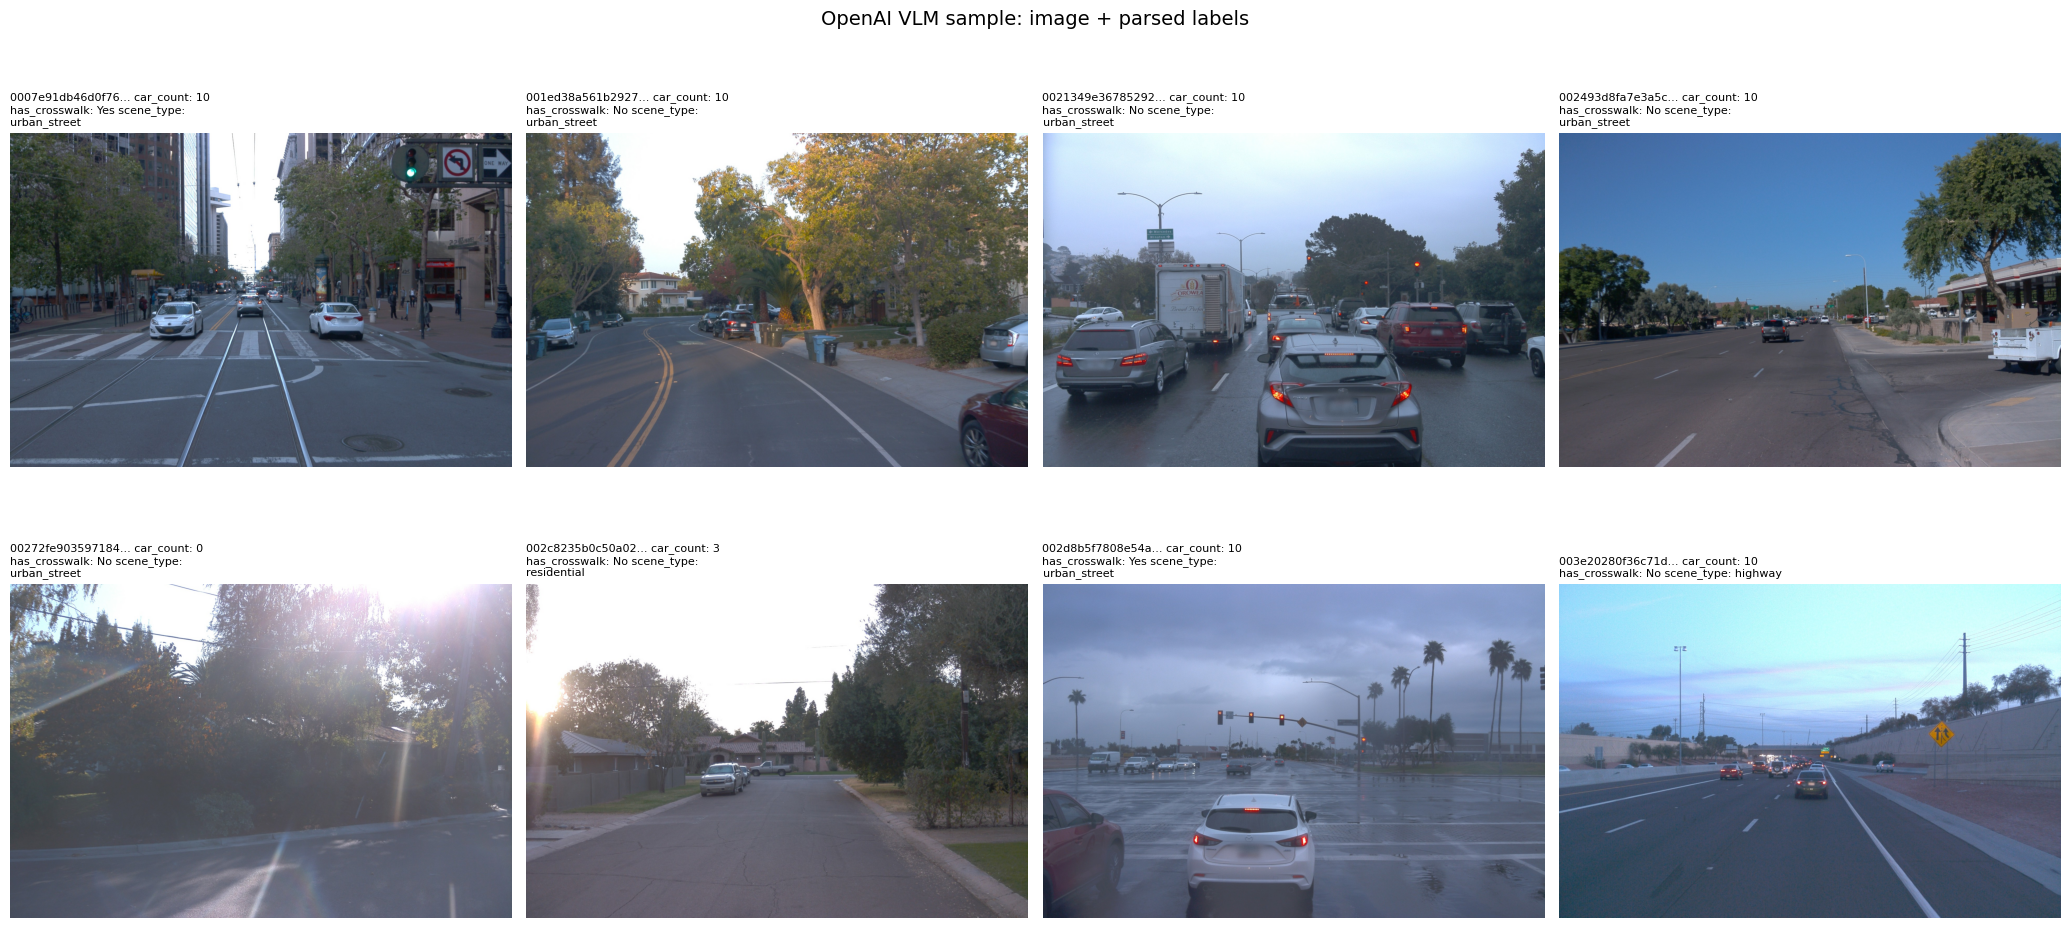

In [15]:
import io
import math
import textwrap
import urllib.parse
import urllib.request

import matplotlib.pyplot as plt
from PIL import Image

if "rows" not in globals():
    raise RuntimeError("Run the read_annotations cell first to fetch rows.")

rows_by_id = {str(r.get("object_id", "")).strip(): (r.get("values", {}) or {}) for r in rows}
object_ids_for_plot = [oid for oid in sample_object_ids if oid in rows_by_id]
if not object_ids_for_plot:
    raise RuntimeError("No annotations found for current sample. Check WRITE_ANNOTATIONS and rerun backfill.")

cols = min(4, max(1, len(object_ids_for_plot)))
rows_count = math.ceil(len(object_ids_for_plot) / cols)
fig, axes = plt.subplots(rows_count, cols, figsize=(cols * 5.2, rows_count * 5.2))
if hasattr(axes, "flat"):
    axes_list = list(axes.flat)
else:
    axes_list = [axes]

for ax in axes_list:
    ax.axis("off")

for idx, object_id in enumerate(object_ids_for_plot):
    ax = axes_list[idx]
    encoded_id = urllib.parse.quote(object_id, safe="")
    image_url = f"{STORAGE_URL.rstrip('/')}/objects/{encoded_id}/content"
    try:
        with urllib.request.urlopen(image_url, timeout=60) as resp:
            image_bytes = resp.read()
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        ax.imshow(image)
    except Exception as exc:
        ax.text(0.5, 0.5, f"Failed to load image\n{object_id[:16]}\n{exc}", ha="center", va="center", fontsize=8)
        continue

    values = rows_by_id.get(object_id, {})
    label_lines = [f"{k}: {values.get(k, '')}" for k in selected_field_names]
    caption = object_id[:16] + "...\n" + "\n".join(label_lines)
    ax.set_title("\n".join(textwrap.wrap(caption, width=38)), fontsize=8, loc="left")

for ax in axes_list[len(object_ids_for_plot):]:
    ax.axis("off")

fig.suptitle("OpenAI VLM sample: image + parsed labels", fontsize=14)
plt.tight_layout()
plt.show()
